The goal of this Notebook is to explore the FITS headers for the few images we have them for and see what the camera might have been doing over the years.

In [2]:
from astropy.io import fits
import pandas as pd
import numpy as np
import dask
import dask.array as da
import dask.dataframe as dd
import matplotlib.pyplot as plt
import os
from glob import glob

First step: How many FITS files do we have?

In [3]:
images = sorted(glob("/home/rainybyte/Downloads/2026/2026/2026-03/*.FIT"))
len(images)

6863

Second step: Which headers do we have?

In [26]:
from astropy.io.fits.hdu.image import ImageHDU, PrimaryHDU
from astropy.io.fits import Header
hdu: PrimaryHDU = fits.open(images[0])[0]
header = hdu.header
header

SIMPLE  =                    T                                                  
BITPIX  =                   16                                                  
NAXIS   =                    2                                                  
NAXIS1  =                  640                                                  
NAXIS2  =                  480                                                  
INSTRUME= 'SBIG AllSky-340'                                                     
DATE-OBS= '2026-03-20T23:44:20.734'                                             
BSCALE  = +1.000000000000E+000                                                  
BZERO   = +3.276800000000E+004                                                  
EXPTIME = +4.830000000000E-002                                                  
CBLACK  =                 1558                                                  
CWHITE  =                13762                                                  

Third step: Examine the extrema of the image

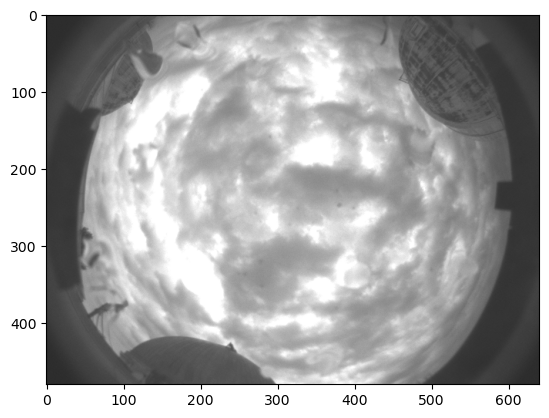

In [57]:
data: np.ndarray[np.uint16] = hdu.data
plt.imshow(data, cmap="gray", vmin=-1558, vmax=13762)

In [49]:
data.min(), data.max()

(np.uint16(1006), np.uint16(22694))

In [47]:
data.ravel().min(), data.ravel().max()

(np.uint16(1006), np.uint16(22694))

Third step: Make a dataframe of all the headers

In [29]:
def extract_fits_headers(images):
    headers = []
    for image in images:
        with fits.open(image) as hdul:
            hdu: PrimaryHDU = hdul[0]
            header = hdu.header
            header_dict = dict(header)
            filename = os.path.basename(image)
            header_dict["fits_filename"] = filename
            header_dict["jpg_filename"] = filename[:-4] + ".JPG"

            data = hdu.data


            headers.append(header_dict)
    return pd.DataFrame(headers)


header_df = extract_fits_headers(images)
header_df = header_df.assign(
    timestamp=pd.to_datetime(
        header_df["DATE-OBS"],
        errors="coerce",
    ))
header_df

,SIMPLE,BITPIX,NAXIS,NAXIS1,NAXIS2,INSTRUME,DATE-OBS,BSCALE,BZERO,EXPTIME,CBLACK,CWHITE,filename,timestamp
0,True,16,2,640,480,SBIG AllSky-340,2026-03-20T23:44:20.734,1.0,32768.0,0.0483,1558,13762,AllSkyImage000418695.FIT,2026-03-20 23:44:20.734
1,True,16,2,640,480,SBIG AllSky-340,2026-03-20T23:45:30.059,1.0,32768.0,0.0702,1524,12874,AllSkyImage000418696.FIT,2026-03-20 23:45:30.059
2,True,16,2,640,480,SBIG AllSky-340,2026-03-20T23:45:49.363,1.0,32768.0,0.1091,1811,19055,AllSkyImage000418697.FIT,2026-03-20 23:45:49.363
3,True,16,2,640,480,SBIG AllSky-340,2026-03-20T23:46:19.437,1.0,32768.0,0.1091,1747,18371,AllSkyImage000418698.FIT,2026-03-20 23:46:19.437
4,True,16,2,640,480,SBIG AllSky-340,2026-03-20T23:46:49.505,1.0,32768.0,0.1091,1695,17963,AllSkyImage000418699.FIT,2026-03-20 23:46:49.505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6858,True,16,2,640,480,SBIG AllSky-340,2026-03-27T02:37:50.253,1.0,32768.0,9.3215,1793,19810,AllSkyImage000425553.FIT,2026-03-27 02:37:50.253
6859,True,16,2,640,480,SBIG AllSky-340,2026-03-27T02:38:49.109,1.0,32768.0,9.3215,1784,18921,AllSkyImage000425554.FIT,2026-03-27 02:38:49.109
6860,True,16,2,640,480,SBIG AllSky-340,2026-03-27T02:43:56.466,1.0,32768.0,9.3215,2115,27824,AllSkyImage000425555.FIT,2026-03-27 02:43:56.466
6861,True,16,2,640,480,SBIG AllSky-340,2026-03-27T02:45:20.036,1.0,32768.0,3.3501,1361,10656,AllSkyImage000425556.FIT,2026-03-27 02:45:20.036


In [58]:
header_df

,SIMPLE,BITPIX,NAXIS,NAXIS1,NAXIS2,INSTRUME,DATE-OBS,BSCALE,BZERO,EXPTIME,CBLACK,CWHITE,filename,timestamp
0,True,16,2,640,480,SBIG AllSky-340,2026-03-20T23:44:20.734,1.0,32768.0,0.0483,1558,13762,AllSkyImage000418695.FIT,2026-03-20 23:44:20.734
1,True,16,2,640,480,SBIG AllSky-340,2026-03-20T23:45:30.059,1.0,32768.0,0.0702,1524,12874,AllSkyImage000418696.FIT,2026-03-20 23:45:30.059
2,True,16,2,640,480,SBIG AllSky-340,2026-03-20T23:45:49.363,1.0,32768.0,0.1091,1811,19055,AllSkyImage000418697.FIT,2026-03-20 23:45:49.363
3,True,16,2,640,480,SBIG AllSky-340,2026-03-20T23:46:19.437,1.0,32768.0,0.1091,1747,18371,AllSkyImage000418698.FIT,2026-03-20 23:46:19.437
4,True,16,2,640,480,SBIG AllSky-340,2026-03-20T23:46:49.505,1.0,32768.0,0.1091,1695,17963,AllSkyImage000418699.FIT,2026-03-20 23:46:49.505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6858,True,16,2,640,480,SBIG AllSky-340,2026-03-27T02:37:50.253,1.0,32768.0,9.3215,1793,19810,AllSkyImage000425553.FIT,2026-03-27 02:37:50.253
6859,True,16,2,640,480,SBIG AllSky-340,2026-03-27T02:38:49.109,1.0,32768.0,9.3215,1784,18921,AllSkyImage000425554.FIT,2026-03-27 02:38:49.109
6860,True,16,2,640,480,SBIG AllSky-340,2026-03-27T02:43:56.466,1.0,32768.0,9.3215,2115,27824,AllSkyImage000425555.FIT,2026-03-27 02:43:56.466
6861,True,16,2,640,480,SBIG AllSky-340,2026-03-27T02:45:20.036,1.0,32768.0,3.3501,1361,10656,AllSkyImage000425556.FIT,2026-03-27 02:45:20.036


These charts demonstrate an implication that, for the most part, the CBLACK and CWHITE which get used to adjust the JPG values are relatively stable while the exposure time is nonzero. The hope is (particularly with further study) that we can trust the pixel values more than expected, provided we adjust against the exposure time.